# <h1><b> NLP: TEXT TAGGING PRACTICAL <b><h1>

In [37]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
pd.set_option("display.max_colwidth", None)

In [38]:
data  = pd.read_csv(r"data\book_reviews_sample.csv")
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.,3
1,984,Alex a sexy hot cop and the PhD candidate. What a match that makes for a great fun and exciting book,4
2,1463,Good thing that this is a free story. I read it a few years ago and it is not worth the time.,1
3,10342,"Action, action, action! Equipment keeps getting blown up, but the heroes live on and on.",4
4,5256,this was hands down the worse book i have ever read and trst me that says alot,1


In [39]:
data["cleaned"]  = data["reviewText"].str.lower()
data["cleaned"].head()

0    clean and funny. a bit busy with all the different plots going on. but overall a good read. bye now.
1    alex a sexy hot cop and the phd candidate. what a match that makes for a great fun and exciting book
2           good thing that this is a free story. i read it a few years ago and it is not worth the time.
3                action, action, action! equipment keeps getting blown up, but the heroes live on and on.
4                          this was hands down the worse book i have ever read and trst me that says alot
Name: cleaned, dtype: str

In [40]:
data["cleaned"] = data["cleaned"].apply(lambda x: re.sub(r"[^\w\s]", "", x))
data["cleaned"]

0        clean and funny a bit busy with all the different plots going on but overall a good read bye now
1     alex a sexy hot cop and the phd candidate what a match that makes for a great fun and exciting book
2             good thing that this is a free story i read it a few years ago and it is not worth the time
3                     action action action equipment keeps getting blown up but the heroes live on and on
4                          this was hands down the worse book i have ever read and trst me that says alot
                                                     ...                                                 
95                   love this author i have read most of her books  and once again she doesnt disappoint
96          this book was not bad i like the storyline  the sex was not that grate and was not much in it
97                this is part of a series i read and i loved the whole series i also have some on kindle
98                                            

In [41]:
data.head()

,index,reviewText,rating,cleaned
0,11494,Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.,3,clean and funny a bit busy with all the different plots going on but overall a good read bye now
1,984,Alex a sexy hot cop and the PhD candidate. What a match that makes for a great fun and exciting book,4,alex a sexy hot cop and the phd candidate what a match that makes for a great fun and exciting book
2,1463,Good thing that this is a free story. I read it a few years ago and it is not worth the time.,1,good thing that this is a free story i read it a few years ago and it is not worth the time
3,10342,"Action, action, action! Equipment keeps getting blown up, but the heroes live on and on.",4,action action action equipment keeps getting blown up but the heroes live on and on
4,5256,this was hands down the worse book i have ever read and trst me that says alot,1,this was hands down the worse book i have ever read and trst me that says alot


In [42]:
vader_sentiment = SentimentIntensityAnalyzer()
data["vader_polarity_score"] = data["cleaned"].apply(lambda review: vader_sentiment.polarity_scores(review)["compound"])
data.head()

,index,reviewText,rating,cleaned,vader_polarity_score
0,11494,Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.,3,clean and funny a bit busy with all the different plots going on but overall a good read bye now,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. What a match that makes for a great fun and exciting book,4,alex a sexy hot cop and the phd candidate what a match that makes for a great fun and exciting book,0.9325
2,1463,Good thing that this is a free story. I read it a few years ago and it is not worth the time.,1,good thing that this is a free story i read it a few years ago and it is not worth the time,0.6740
3,10342,"Action, action, action! Equipment keeps getting blown up, but the heroes live on and on.",4,action action action equipment keeps getting blown up but the heroes live on and on,0.6652
4,5256,this was hands down the worse book i have ever read and trst me that says alot,1,this was hands down the worse book i have ever read and trst me that says alot,-0.4767


In [43]:
bins = [-1, -0.1, 0.1, 1]
bins_labels = ["negative", "neutral", "positive"]
# /data["vadar_sentiment_label"] = data["vader_polarity_score"].apply(lambda polarity: "positive" if polarity > 0 else "negative" if polarity < 0 else "nuetural")
data["vadar_sentiment_label"] = pd.cut(data["vader_polarity_score"], bins, labels=bins_labels)
data.head()

,index,reviewText,rating,cleaned,vader_polarity_score,vadar_sentiment_label
0,11494,Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.,3,clean and funny a bit busy with all the different plots going on but overall a good read bye now,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. What a match that makes for a great fun and exciting book,4,alex a sexy hot cop and the phd candidate what a match that makes for a great fun and exciting book,0.9325,positive
2,1463,Good thing that this is a free story. I read it a few years ago and it is not worth the time.,1,good thing that this is a free story i read it a few years ago and it is not worth the time,0.6740,positive
3,10342,"Action, action, action! Equipment keeps getting blown up, but the heroes live on and on.",4,action action action equipment keeps getting blown up but the heroes live on and on,0.6652,positive
4,5256,this was hands down the worse book i have ever read and trst me that says alot,1,this was hands down the worse book i have ever read and trst me that says alot,-0.4767,negative


<Axes: xlabel='vadar_sentiment_label'>

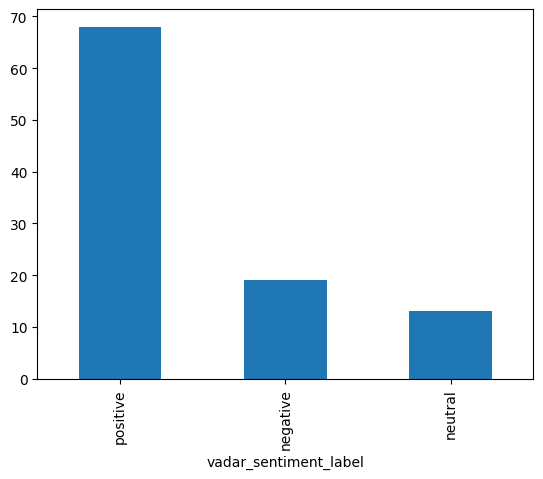

In [44]:
# bar chart
data["vadar_sentiment_label"].value_counts().plot.bar()

In [45]:
transformer_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [48]:
transformer_labels = []

for review in data["cleaned"]:
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(sentiment_label[0])
transformer_labels

['POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'POSITIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'POSITIVE',
 'NEGATIVE',
 'NEGATIVE',
 'NEGATIVE',

In [49]:
data["transformer_sentiment_labels"] = transformer_labels
data.head()

,index,reviewText,rating,cleaned,vader_polarity_score,vadar_sentiment_label,transformer_sentiment_labels
0,11494,Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.,3,clean and funny a bit busy with all the different plots going on but overall a good read bye now,0.7684,positive,POSITIVE
1,984,Alex a sexy hot cop and the PhD candidate. What a match that makes for a great fun and exciting book,4,alex a sexy hot cop and the phd candidate what a match that makes for a great fun and exciting book,0.9325,positive,POSITIVE
2,1463,Good thing that this is a free story. I read it a few years ago and it is not worth the time.,1,good thing that this is a free story i read it a few years ago and it is not worth the time,0.6740,positive,NEGATIVE
3,10342,"Action, action, action! Equipment keeps getting blown up, but the heroes live on and on.",4,action action action equipment keeps getting blown up but the heroes live on and on,0.6652,positive,NEGATIVE
4,5256,this was hands down the worse book i have ever read and trst me that says alot,1,this was hands down the worse book i have ever read and trst me that says alot,-0.4767,negative,NEGATIVE


In [50]:
data.tail()

,index,reviewText,rating,cleaned,vader_polarity_score,vadar_sentiment_label,transformer_sentiment_labels
95,1794,"Love this author. I have read most of her books, and once again, she doesn't disappoint!!!!",5,love this author i have read most of her books and once again she doesnt disappoint,0.7549,positive,POSITIVE
96,6716,This book was not bad! I like the storyline ! The sex was not that grate and was not much in it!,2,this book was not bad i like the storyline the sex was not that grate and was not much in it,0.1877,positive,NEGATIVE
97,7372,This is part of a series I read and I loved the whole series I also have some on Kindle.,5,this is part of a series i read and i loved the whole series i also have some on kindle,0.5994,positive,POSITIVE
98,5676,Finally a Texas newspaper in Kindle format.Way to go Amazon !!,4,finally a texas newspaper in kindle formatway to go amazon,0.1779,positive,NEGATIVE
99,7737,TJ and Jon are very HOT in this book. Christine finds love and pleasure she did not no exsited .,5,tj and jon are very hot in this book christine finds love and pleasure she did not no exsited,0.8686,positive,POSITIVE


<Axes: xlabel='transformer_sentiment_labels'>

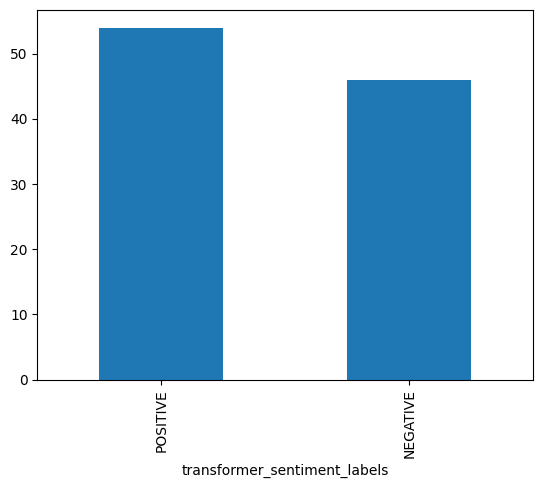

In [51]:
data["transformer_sentiment_labels"].value_counts().plot.bar()